In [136]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [137]:
df = pd.read_csv(
    "../data/processed/bitcoin_features.csv"
)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_return,Volatility,MA7,...,Avg_gain,Avg_loss,RS,RSI,EMA12,EMA26,MACD,MACD_ratio,Return_7D,Return_30D
0,2014-12-15,351.360992,351.815002,344.933990,345.345001,345.345001,17264200,-0.017879,0.021259,349.426426,...,1.433071,3.854499,0.371792,27.102635,356.422929,362.574433,-6.151504,-0.017813,-0.045768,-0.081854
1,2014-12-16,345.673004,345.859009,327.062012,327.062012,327.062012,30864900,-0.052941,0.022171,345.832572,...,1.285213,5.160427,0.249052,19.939262,351.905865,359.943883,-8.038018,-0.024576,-0.071424,-0.156800
2,2014-12-17,326.855011,333.954010,315.152008,319.776001,319.776001,37567900,-0.022277,0.022366,342.034145,...,1.285213,5.230499,0.245715,19.724827,346.962809,356.968485,-10.005676,-0.031290,-0.076766,-0.174576
3,2014-12-18,319.785004,323.709015,304.231995,311.395996,311.395996,39173000,-0.026206,0.022178,336.447000,...,1.285213,5.442928,0.236125,19.102052,341.490992,353.592745,-12.101753,-0.038863,-0.111582,-0.170049
4,2014-12-19,311.178986,318.532990,306.769012,317.842987,317.842987,23823100,0.020704,0.022410,331.489999,...,1.227855,5.442928,0.225587,18.406462,337.852837,350.944614,-13.091777,-0.041189,-0.098425,-0.164791


# Predicting Bitcoin Direction

Objective:

Investigate whether technical indicators can predict future Bitcoin price movement.

In [138]:
df["Target"]=(df["Close"].shift(-1)>df["Close"]).astype(int)
df["target_7D"]=(df["Close"].shift(-7)>df["Close"]).astype(int)

In [139]:
df["Target"].tail(10)

4181    0
4182    0
4183    1
4184    0
4185    0
4186    0
4187    0
4188    0
4189    0
4190    0
Name: Target, dtype: int64

In [140]:
df["Target"].value_counts()

Target
1    2199
0    1992
Name: count, dtype: int64

In [141]:
df_ml=df.dropna().copy()
df_ml.shape

(4191, 30)

In [142]:
corr=df_ml[["Target","MACD"]].corr()
print(corr)

         Target     MACD
Target  1.00000  0.00317
MACD    0.00317  1.00000


In [143]:
corr=df_ml[["Target","MACD_ratio"]].corr()
print(corr)

              Target  MACD_ratio
Target      1.000000    0.024573
MACD_ratio  0.024573    1.000000


In [144]:
corr=df[["Return_7D","Return_30D","Target"]].corr()
print(corr)

            Return_7D  Return_30D    Target
Return_7D    1.000000    0.505082 -0.002289
Return_30D   0.505082    1.000000  0.015940
Target      -0.002289    0.015940  1.000000


In [145]:
features=["Daily_return","Volatility","RSI","Close_vs_MA30_ratio","MA7_vs_MA30_ratio","Return_7D","Return_30D"]

In [146]:
X=df_ml[features]
Y=df_ml["Target"]
Z=df_ml["target_7D"]
print(X.head())
print()
print(Y.head())
print()
print(Z.head())

   Daily_return  Volatility        RSI  Close_vs_MA30_ratio  \
0     -0.017879    0.021259  27.102635             0.940115   
1     -0.052941    0.022171  19.939262             0.895285   
2     -0.022277    0.022366  19.724827             0.880776   
3     -0.026206    0.022178  19.102052             0.862748   
4      0.020704    0.022410  18.406462             0.885740   

   MA7_vs_MA30_ratio  Return_7D  Return_30D  
0           0.951226  -0.045768   -0.081854  
1           0.946667  -0.071424   -0.156800  
2           0.942083  -0.076766   -0.174576  
3           0.932154  -0.111582   -0.170049  
4           0.923771  -0.098425   -0.164791  

0    0
1    0
2    0
3    1
4    1
Name: Target, dtype: int64

0    0
1    1
2    1
3    1
4    1
Name: target_7D, dtype: int64


In [147]:
split=int(len(df_ml)*0.8)
X_train=X[:split]
X_test=X[split:]
Y_train=Y[:split]
Y_test=Y[split:]
Z_train=Z[:split]
Z_test=Z[split:]

In [148]:
print(X_train.shape)
print(X_test.shape)

(3352, 7)
(839, 7)


In [149]:
model1=LogisticRegression(max_iter=1000)
model1.fit(X_train,Y_train)
model2=LogisticRegression(max_iter=1000)
model2.fit(X_train,Z_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [150]:
pred1=model1.predict(X_test)
pred2=model2.predict(X_test)

In [151]:
accuracy1=accuracy_score(Y_test,pred1)
print(accuracy1)
accuracy2=accuracy_score(Z_test,pred2)
print(accuracy2)

0.48867699642431467
0.5065554231227652


In [152]:
print(classification_report(Y_test,pred1))
print(classification_report(Z_test,pred2))

              precision    recall  f1-score   support

           0       0.45      0.09      0.14       421
           1       0.49      0.89      0.64       418

    accuracy                           0.49       839
   macro avg       0.47      0.49      0.39       839
weighted avg       0.47      0.49      0.39       839

              precision    recall  f1-score   support

           0       0.44      0.08      0.13       405
           1       0.51      0.91      0.66       434

    accuracy                           0.51       839
   macro avg       0.47      0.49      0.39       839
weighted avg       0.48      0.51      0.40       839



In [153]:
for feature, coef in zip(features,model1.coef_[0]):
  print(feature, coef)

Daily_return -1.5645713579467369
Volatility -0.1644866776914306
RSI 0.007162551926200228
Close_vs_MA30_ratio -0.5768389242629828
MA7_vs_MA30_ratio 0.4311827186948019
Return_7D -0.292361203254193
Return_30D -0.014704905696865328


In [154]:
corr = df_ml[[
    "Daily_return",
    "Volatility",
    "RSI",
    "Close_vs_MA30_ratio",
    "MA7_vs_MA30_ratio",
    "target_7D"
]].corr()

print(corr["target_7D"].sort_values(ascending=False))

target_7D              1.000000
RSI                    0.060660
MA7_vs_MA30_ratio      0.042103
Close_vs_MA30_ratio    0.036254
Volatility             0.002403
Daily_return          -0.013400
Name: target_7D, dtype: float64


# Random Forest Classification

Unlike Logistic Regression, Random Forest can learn non-linear relationships and interactions between features.

Objective:
Determine whether a more powerful model can extract predictive signals from technical indicators.

In [155]:
rf=RandomForestClassifier(n_estimators=200,max_depth=5,random_state=42)
rf.fit(X_train,Y_train)
pred_rf=rf.predict(X_test)

In [156]:
rf_acc=accuracy_score(Y_test,pred_rf)
print(rf_acc)

0.5148986889153755


In [157]:
print(classification_report(Y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.52      0.36      0.42       421
           1       0.51      0.67      0.58       418

    accuracy                           0.51       839
   macro avg       0.52      0.52      0.50       839
weighted avg       0.52      0.51      0.50       839



In [158]:
importance_df=pd.DataFrame({"Feature":features,"Importance":rf.feature_importances_})
importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
0,Daily_return,0.183731
2,RSI,0.154056
1,Volatility,0.149797
5,Return_7D,0.133743
4,MA7_vs_MA30_ratio,0.130826
6,Return_30D,0.124551
3,Close_vs_MA30_ratio,0.123296


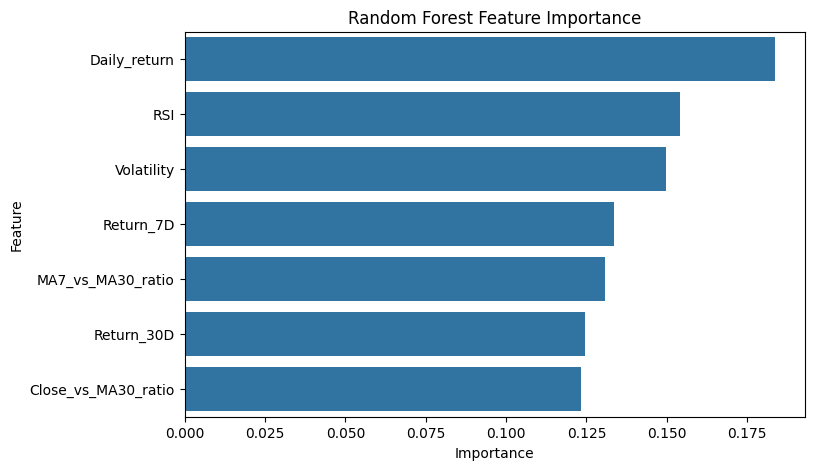

In [159]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.savefig(
    "../figures/rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()